# Análise exploratoria dos dados

## Exercícios

## 1. Gere amostras de distribuições de Poisson com diferentes valores de $\lambda$. Para cada amostra, calcule a média e o desvio-padrão. Em seguida, faça um gráfico da média em função do desvio-padrão. O que você observa?

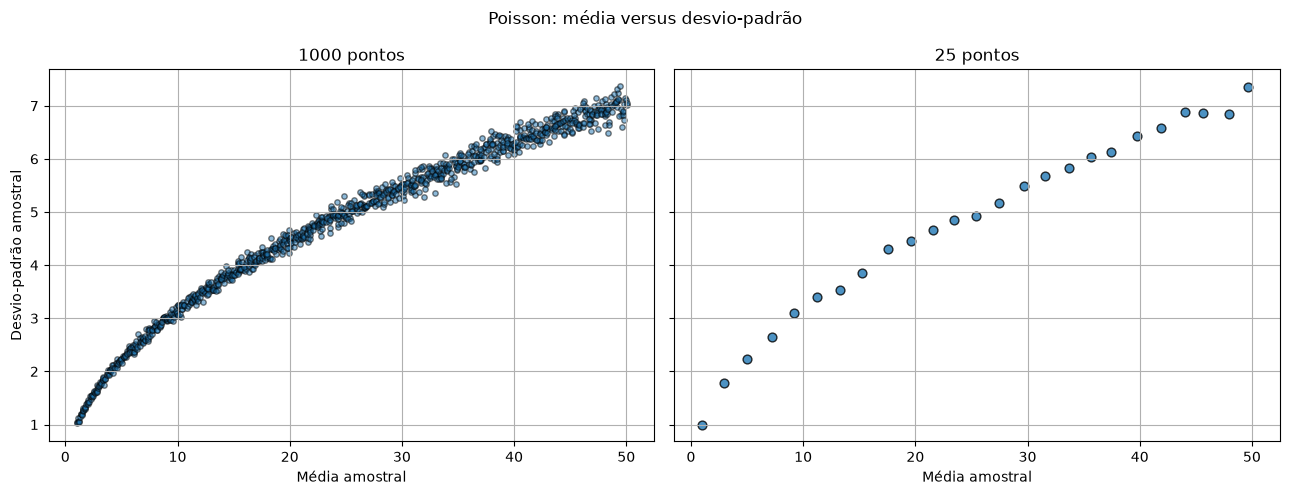

In [98]:
import numpy as np
import matplotlib.pyplot as plt

def media_desvio(n_pontos, size=1000, lamb_max=50):
    lambdas = np.linspace(1, lamb_max, n_pontos)
    medias, desvios = [], []
    for lamb in lambdas:
        amostra = np.random.poisson(lam=lamb, size=size)
        medias.append(np.mean(amostra))
        desvios.append(np.std(amostra))
    return medias, desvios

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

# Esquerda: 1000 pontos
m, d = media_desvio(1000)
axes[0].scatter(m, d, s=15, alpha=0.5, edgecolor="black")
axes[0].set_title("1000 pontos")
axes[0].set_xlabel("Média amostral")
axes[0].set_ylabel("Desvio-padrão amostral")
axes[0].grid(True)

# Direita: 25 pontos
m, d = media_desvio(25)
axes[1].scatter(m, d, s=40, alpha=0.8, edgecolor="black")
axes[1].set_title("25 pontos")
axes[1].set_xlabel("Média amostral")
axes[1].grid(True)

fig.suptitle("Poisson: média versus desvio-padrão")
plt.tight_layout()
plt.show()

O gráfico mostra que o desvio-padrão aumenta conforme a média aumenta, mas de forma não-linear.

Quando aumenta o número de pontos (testei com 1000) parece haver uma curva côncava.

## 2. Considere a base Iris. Calcule, para cada variável numérica, a média, a variância, o desvio-padrão e o intervalo interquartil.

In [99]:
import pandas as pd
import numpy as np

def estatisticas_descritivas(data):
    # média
    media = np.mean(data)
    # variância
    variancia = np.var(data)
    # DP
    desvpad = np.std(data)
    # IQR
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    # outputs
    print(f"A média é {media:.2f}")
    print(f"A variância é {variancia:.2f}")
    print(f"O desvio padrão é {desvpad:.2f}")
    print(f"O IQR é {iqr:.2f}")

# Lê os dados
df = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv")

# seleciona apenas as variáveis numéricas
df_num = df.select_dtypes(include=np.number)

# aplica as estatísticas para cada variável numérica
for coluna in df_num.columns:
    print(f"\n=== {coluna} ===")
    estatisticas_descritivas(df_num[coluna])


=== sepal_length ===
A média é 5.84
A variância é 0.68
O desvio padrão é 0.83
O IQR é 1.30

=== sepal_width ===
A média é 3.05
A variância é 0.19
O desvio padrão é 0.43
O IQR é 0.50

=== petal_length ===
A média é 3.76
A variância é 3.09
O desvio padrão é 1.76
O IQR é 3.50

=== petal_width ===
A média é 1.20
A variância é 0.58
O desvio padrão é 0.76
O IQR é 1.50


## 3. Obtenha o boxplot de todas as variáveis da base Iris, separando os resultados por espécie.

In [100]:
axes

array([<Axes: title={'center': '1000 pontos'}, xlabel='Média amostral', ylabel='Desvio-padrão amostral'>,
       <Axes: title={'center': '25 pontos'}, xlabel='Média amostral'>],
      dtype=object)

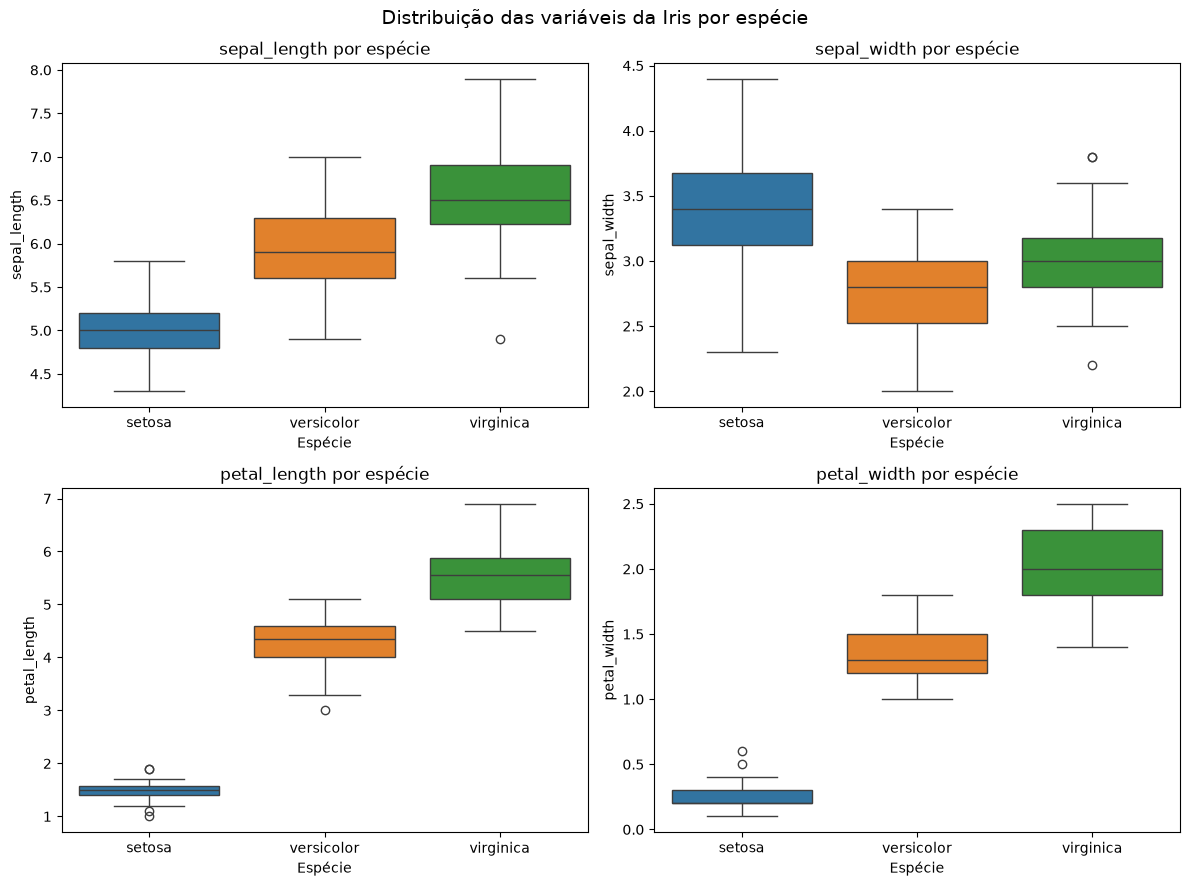

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Lê os dados
data = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv")

# variáveis numéricas a plotar
variaveis = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()  # transforma a matriz 2x2 numa lista de 4 eixos

for ax, var in zip(axes, variaveis):
    sns.boxplot(data=data, 
                x="species", 
                y=var, 
                hue="species",
                ax=ax)
    ax.set_title(f"{var} por espécie")
    ax.set_xlabel("Espécie")
    ax.set_ylabel(var)

fig.suptitle("Distribuição das variáveis da Iris por espécie", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Calcule a matriz de correlação de Pearson da base Iris. Quais pares de variáveis possuem maior correlação positiva?

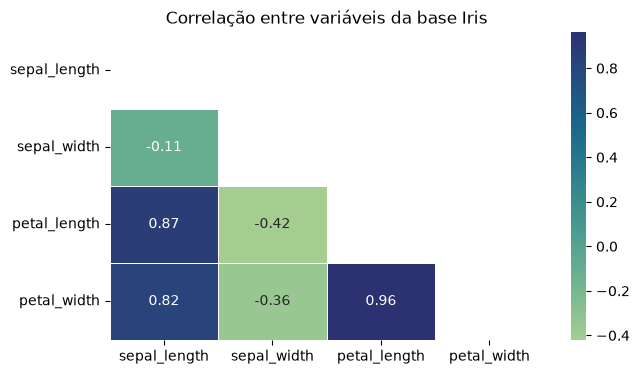

In [102]:
import seaborn as sns

df_num = df.select_dtypes(include=np.number)

# Calcula as correlações Pearson
corr = df_num.corr('pearson')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7, 4))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()


As correlações positivas mais fortes da base Iris são:

1. `petal_length × petal_width = 0,96`

2. `sepal_length × petal_length = 0,87`

3. `sepal_length × petal_width = 0,82`

## 5. Calcule a matriz de correlação de Spearman da base Iris. Os resultados são semelhantes aos obtidos com Pearson?

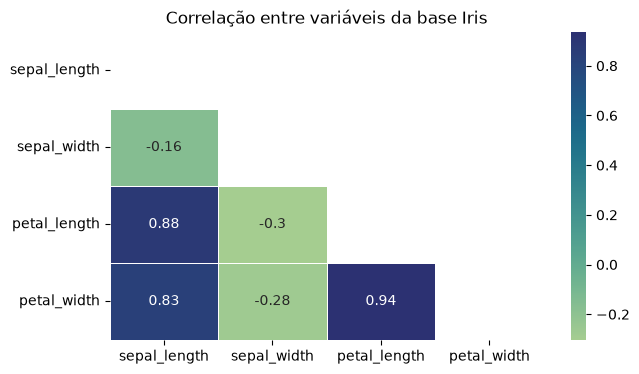

In [103]:
import seaborn as sns

df_num = df.select_dtypes(include=np.number)

# Calcula as correlações Pearson
corr = df_num.corr('spearman')

# Cria a máscara do triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(7, 4))

sns.heatmap(data=corr,
            mask=mask, # apresenta em forma de triangulo, evitando apresentar 2x os mesmos resultados
            annot=True,
            linewidth=.5,
            cmap=sns.color_palette("crest", as_cmap=True))

plt.title("Correlação entre variáveis da base Iris")
plt.show()

Sim, muito semelhantes!!! 

A estrutura geral é a mesma: os mesmos três pares aparecem como os mais fortes, na mesma ordem, e o sinal (positivo/negativo) de todos os pares é idêntico nos dois métodos.

## 6. Escolha uma base de dados real de seu interesse e realize uma análise exploratória inicial contendo: resumo estatístico, histogramas, boxplots e matriz de correlação.